# Tutorial 9: Support Vector Machines
## Connect representation, margins, support vectors, and kernels to ad-click classification

**Course:** IE 1171  
**Original files:** `Ad_click_prediction_train.csv` and `Ad_Click_prediciton_test.csv`  
**Level 1:** Required core—linear support-vector classifier and the kernel method  
**Level 2:** Optional deep dive—training-only tuning and subgroup error audit

---

This tutorial creates one labeled training/test split from `Ad_click_prediction_train.csv`. The external file is inspected but never presented as labeled evaluation data.


# 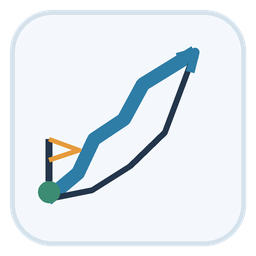 Learning Objectives

By the end of this tutorial, you should be able to:

1. **Understand SVM geometry**
   - Explain a separating hyperplane, margin, and support vectors.
   - Explain why a soft margin permits some violations.
   - Describe how `C` changes the fit–margin tradeoff.
2. **Build and compare SVM classifiers**
   - Create a numeric representation, exclude tracking identifiers, and standardize numeric inputs.
   - Fit linear and radial-basis-function classifiers with Claude-generated Python.
   - Evaluate the rare click group with decision scores and complementary measures.
3. **Examine tuning and group effects**
   - Explain how `C` and `gamma` affect an RBF boundary.
   - Use training-only cross-validation before final evaluation.
   - Audit errors by the supplied gender group without claiming causation.


# Pólya’s Four-Step Problem-Solving Cycle

> **Backbone for this tutorial:** George Pólya’s four steps organize the work from problem framing through verification. The steps are a **cycle**, not a one-way checklist: if later evidence exposes a bad assumption, return to the earlier step that needs revision.

| Marker | Pólya step | Guiding question | In this tutorial |
|---|---|---|---|
| **🔵 🧭** | **Understand the Problem** | What is the real problem, what is known, and what constraints define success? | Define the click-classification goal, variables, and what a useful boundary should accomplish. |
| **🟣 🗺️** | **Devise a Plan** | What sequence of actions and checks should connect the current state to the goal? | Plan standardization, encoding, the data split, and the linear-versus-kernel comparison. |
| **🟠 🛠️** | **Carry Out the Plan** | Can the plan be executed in small, observable steps and checked as it runs? | Fit and evaluate the SVM models without changing the evaluation target after seeing results. |
| **🟢 🔎** | **Look Back** | Does the result answer the original problem, and what should be revised or generalized? | Inspect boundary errors, tuning sensitivity, group performance, and interpretation limits. |

The colored markers reappear at the points where each step becomes the main focus. **Human Checks support the cycle, but they are not a universal checklist:** meaningful verification depends on domain knowledge, the data-generating process, and the consequences of being wrong.


# 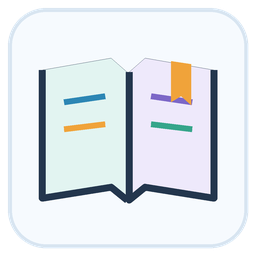 Assigned Reading

## Statistical Reading Retained From the Original Tutorial

**James et al., _An Introduction to Statistical Learning with Applications in Python_ (ISLP)**

- Section 9.1: Maximal Margin Classifier
- Section 9.2: Support Vector Classifiers
- Section 9.3: Support Vector Machines

Focus on hyperplanes, margins, support vectors, soft-margin violations, the tuning parameter `C`, enlarged feature spaces, linear/polynomial/radial kernels, and the kernel representation.

The social-good section later in the notebook uses the earlier course’s platform, recommendation, and accountability themes as **background context, not as additional assigned reading**.

Level 1 and Level 2 use the same ISLP reading and the same original ad-click files.


# 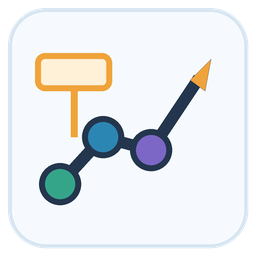 Tutorial Flow

| Section | Purpose |
|---|---|
| **Theory** | Connect the code to the geometry and representation in Chapter 9. |
| **Manual Pause** | Predict a modeling choice before asking Claude. |
| **Without Claude** | Identify preprocessing and alignment risks. |
| **Claude Coding Task** | Request one focused and checkable program. |
| **Your Workspace** | Read and run Claude's response. |
| **Reference Solution** | Compare only after making your own attempt. |
| **Human Check** | Verify the representation, label, split, and metric. |
| **Look Back** | Interpret the boundary and examine who is affected. |

> An SVM separates represented observations. If the representation is weak or misleading, the boundary will be too.


## Tutorial Symbols

| Symbol | Meaning | What to do |
|---|---|---|
| **🔵 🧭  🟣 🗺️  🟠 🛠️  🟢 🔎** | **Pólya Backbone** | Treat the four colored checkpoints as the main problem-solving cycle; return to an earlier step when new evidence requires revision. |
| 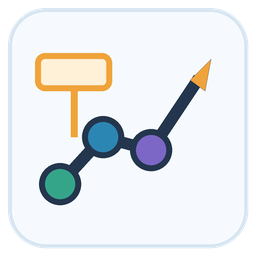 | **Tutorial Flow** | Follow the notebook’s normal route. |
| 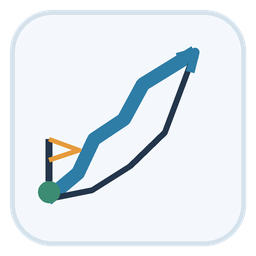 | **Learning Objectives** | See the three destinations for the tutorial. |
| 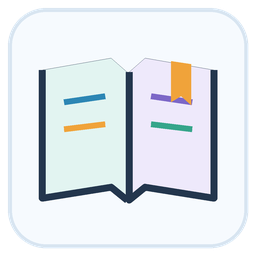 | **Assigned Reading** | Read the named sections before or alongside the notebook. |
| 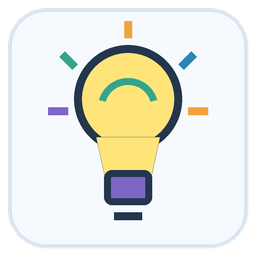 | **Theory** | Connect the assigned reading to the current part. |
| 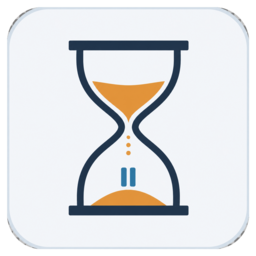 | **Manual Pause** | Think or predict before asking Claude. |
| 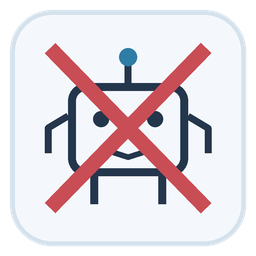 | **Without Claude** | Notice the programming details Claude can coordinate. |
| 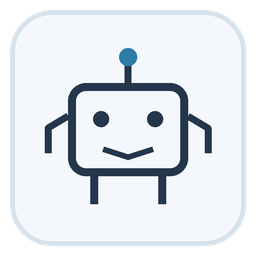 | **Claude Task** | Use one focused and checkable prompt. |
| 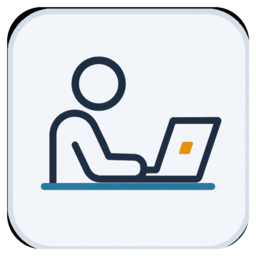 | **Your Workspace** | Paste, read, and run Claude’s response. |
| 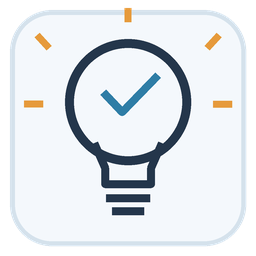 | **Reference Solution** | Compare only after your own attempt. |
| 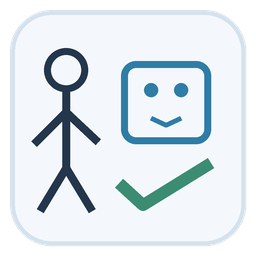 | **Human Check — domain expertise required** | Use the provided questions, then add a domain-specific check. The notebook cannot supply a complete checklist for every application. |
| 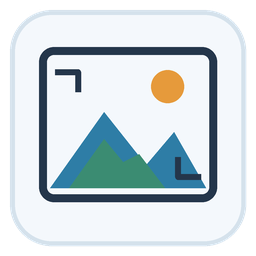 | **Look Back** | Interpret, challenge, and reflect on the result. |
| 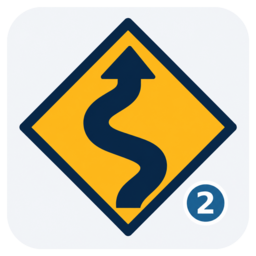 | **Level 2 — Challenge Ahead** | Take the optional harder route after Level 1. |

> **Important — Human Checks are not a complete checklist.** The notebook can suggest generic verification questions, but deciding what *must* be checked depends on knowledge of the domain, the data-generating process, and the consequences of an error. If you do not have that expertise, involve someone who does. Every Human Check asks you to add your own domain-specific question.

# 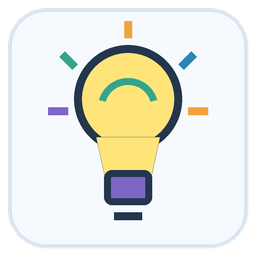 Theory Foundation: Margins, Hinge Loss, and Kernels

A linear support-vector classifier uses a hyperplane $f(x)=w^Tx+b$. The sign gives the predicted class and the geometric distance to the boundary is proportional to $|w^Tx+b|/\lVert w\rVert_2$. For separable data, maximizing the margin is equivalent to minimizing $\frac12\lVert w\rVert_2^2$ subject to correct classifications outside the margin.

Real data require violations. The soft-margin objective can be written

$$
\min_{w,b}\ \frac12\lVert w\rVert_2^2
+C\sum_{i=1}^{n}\max\bigl(0,1-y_i(w^Tx_i+b)\bigr),
$$

where $y_i\in\{-1,+1\}$. The hinge loss is zero only when a point is correctly classified with sufficient margin. Large $C$ penalizes violations strongly and tends toward a narrower, less regularized boundary; small $C$ tolerates more violations for a wider margin.

Only points on or inside the margin influence the final boundary strongly; these are the **support vectors**. Scaling matters because both dot products and distances depend on feature units. Preprocessing must be fitted inside each training fold to prevent validation leakage.

Kernels replace explicit dot products with similarity functions. The radial-basis kernel is

$$
K(x,z)=\exp(-\gamma\lVert x-z\rVert_2^2).
$$

Large $\gamma$ makes influence very local and permits a wiggly boundary; small $\gamma$ creates smoother, broader influence. The kernel trick allows a linear separator in an implicit feature space without constructing every transformed feature. It does not eliminate tuning, scaling, or interpretability concerns.

SVM decision scores are margins, not probabilities. Probability calibration is an additional fitted layer. As with other classifiers, threshold-independent discrimination does not choose an ethically acceptable operating point.

### Questions you should be ready to answer

- What is the difference between a boundary and its margin?
- Which observations become support vectors?
- How do $C$ and $\gamma$ change different aspects of flexibility?
- Why is an SVM score not automatically a probability?

## 🔵 🧭 Pólya Step 1 — Understand the Problem

**Backbone checkpoint.** State the real goal, evidence, constraints, and what would count as success before asking an AI system to solve anything.

**In this tutorial:** Define the click-classification goal, variables, and what a useful boundary should accomplish.

# Level 1 — Required Core

# Part 1: Define the Click-Classification Problem

The response in the labeled training file is:

$$Y=\texttt{is\_click}\in\{0,1\}.$$

The original fields include session and user identifiers, time, product and campaign fields, demographic or profile codes, and the click outcome.

The external file `Ad_Click_prediciton_test.csv` intentionally lacks the response. Predictions can be generated for it, but accuracy cannot be computed unless true outcomes are later supplied.

## 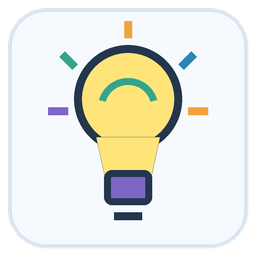 Theory: Hyperplanes and Margins

A linear boundary in represented predictor space has the form:

$$
\beta_0+\beta_1X_1+\cdots+\beta_pX_p=0.
$$

The sign determines the predicted side. The maximal-margin idea selects a separating boundary with a wide gap between classes. A support-vector classifier allows violations so it can handle overlap and reduce sensitivity to individual observations.


## 🟣 🗺️ Pólya Step 2 — Devise a Plan

**Backbone checkpoint.** Decide the sequence of actions and checks before the main execution. Make assumptions, evaluation rules, and stopping conditions visible so they can be challenged.

**In this tutorial:** Plan standardization, encoding, the data split, and the linear-versus-kernel comparison.

## 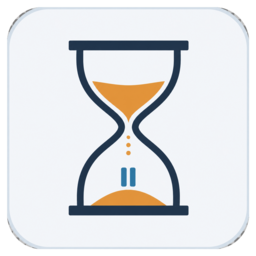 Manual Pause: Reason About Representation

1. What does class `1` mean?
2. Why is `session_id` an identifier rather than a behavioral measurement?
3. Why might `campaign_id` create memorization instead of generalization?
4. Is `product` numeric or categorical?
5. What useful features can be derived from `DateTime`?
6. Why should numeric predictors be scaled for an SVM?
7. Why should a scaler be fit only on training data?
8. If clicks are rare, why can accuracy look strong while recall is poor?
9. Why can the external test file not provide an accuracy score?


## 🟠 🛠️ Pólya Step 3 — Carry Out the Plan

**Backbone checkpoint.** Execute in small, observable steps. Read generated code or actions, stay within scope, and compare outputs with the behavior you predicted.

**In this tutorial:** Fit and evaluate the SVM models without changing the evaluation target after seeing results.

## 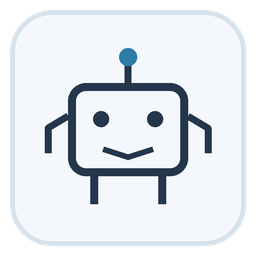 Claude Coding Task 1: Load and Audit Both Original Files

```text
Act as a careful Python tutor.

Write one Jupyter Notebook code cell that:

1. imports pathlib and pandas;
2. loads Ad_click_prediction_train.csv as ad_train;
3. loads Ad_Click_prediciton_test.csv as ad_external_test;
4. prints shape, first five rows, missing-value counts, and data types for both;
5. verifies that is_click exists in ad_train;
6. reports whether is_click exists in ad_external_test;
7. prints training class counts and proportions;
8. reports duplicate session_id values when that column exists;
9. reports the number of unique values in each training column;
10. does not preprocess or fit a model.

Preserve the unusual original spelling prediciton in the external filename.
Return only the Python code.
```

### 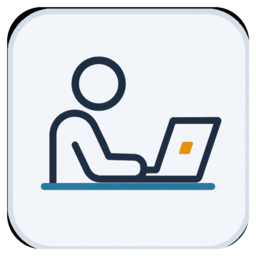 Your Workspace

Paste, read, and run Claude's response in the next cell.


In [ ]:
# YOUR WORKSPACE — Claude Coding Task 1


### 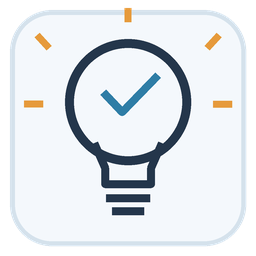 Reference Solution for Task 1


In [ ]:
from pathlib import Path
import pandas as pd

train_path = Path("Ad_click_prediction_train.csv")
external_path = Path("Ad_Click_prediciton_test.csv")
assert train_path.exists(), f"File not found: {train_path.resolve()}"
assert external_path.exists(), f"File not found: {external_path.resolve()}"

ad_train = pd.read_csv(train_path)
ad_external_test = pd.read_csv(external_path)
assert "is_click" in ad_train.columns, "The labeled training file needs is_click."

for name, frame in [("Training", ad_train), ("External test", ad_external_test)]:
    print(f"\n{name} shape: {frame.shape}")
    display(frame.head())
    display(frame.isna().sum().to_frame("missing_count"))
    display(frame.dtypes.to_frame("dtype"))

print("External test contains is_click:", "is_click" in ad_external_test.columns)
print("\nTraining class counts and proportions:")
display(pd.concat([
    ad_train["is_click"].value_counts(dropna=False).rename("count"),
    ad_train["is_click"].value_counts(normalize=True, dropna=False).rename("proportion"),
], axis=1))
if "session_id" in ad_train.columns:
    print("Duplicate training session_id values:", int(ad_train["session_id"].duplicated().sum()))
display(ad_train.nunique(dropna=False).sort_values(ascending=False).to_frame("unique_count"))


### 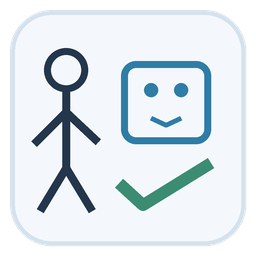 Human Check

> **Domain expertise required:** The questions below are examples, not a complete checklist. Add a check based on the real application; if you lack that expertise, involve someone who has it.

- **Your own domain question:** What could be wrong here that a generic AI system or checklist would be unlikely to notice?


- Is `is_click` binary?
- How rare is the clicked class?
- Which columns have high cardinality?
- Do the two files use matching predictor names?
- Does the external file truly omit `is_click`?
- Are missing values concentrated in specific fields?
- Did Claude avoid inventing external labels?

# Part 2: Build the SVM Representation

Representation determines geometry.

This tutorial:

- excludes `session_id`, `user_id`, `campaign_id`, `webpage_id`, and `user_group_id` as high-cardinality identifiers;
- derives hour and day of week from `DateTime`;
- one-hot encodes categorical fields;
- imputes and scales numeric fields;
- takes a fixed stratified sample when the original file is very large so the kernel SVM remains practical.

These are explicit teaching decisions. Another intended use may justify a different representation.


## 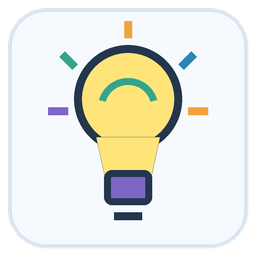 Theory: Standardization Changes SVM Geometry

Distances and inner products determine the SVM boundary. Without standardization, a numeric variable with large units can dominate that geometry. Standardization centers and rescales numeric predictors using training information; one-hot encoding represents categories without inventing an order. Both choices become part of the model.

### Deeper explanation

Replacing $X_j$ by $(X_j-\mu_j)/\sigma_j$ makes one unit mean one training standard deviation. Without scaling, a feature measured in thousands can dominate $\lVert x-z\rVert^2$ and the orientation of $w$. Means and standard deviations must be estimated on training folds only. Binary indicators may still be scaled depending on the intended geometry, but the choice should be documented.


## 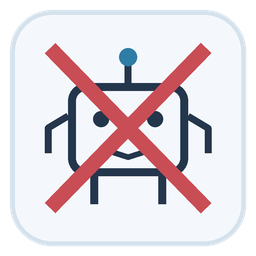 Without Claude: Why This Is Easy to Misalign

A correct pipeline must coordinate:

1. feature engineering in both future and training data;
2. identifier removal;
3. numeric versus categorical roles;
4. missing-value handling;
5. scaling learned only from training observations;
6. categories that appear in only one split;
7. a reproducible sample and a reproducible split;
8. the same row labels throughout evaluation.


## 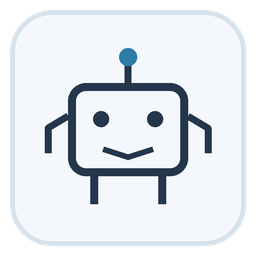 Claude Coding Task 2: Create the Representation and Locked Split

```text
Using ad_train, write one Jupyter Notebook code cell that:

1. parses DateTime with errors="coerce" and derives hour and day_of_week;
2. removes session_id, user_id, campaign_id, webpage_id, user_group_id,
   DateTime, and is_click from the predictors when present;
3. treats product, gender, product_category_1, and product_category_2 as
   categorical when present;
4. treats remaining predictor columns as numeric, converting with
   errors="coerce";
5. drops rows with missing is_click and verifies labels are 0 or 1;
6. if more than 12000 rows remain, takes a stratified 12000-row sample with
   random_state=1099;
7. creates one 80/20 stratified split with random_state=1099;
8. creates a ColumnTransformer that imputes and scales numeric features and
   imputes and one-hot encodes categorical features;
9. does not fit the preprocessor separately;
10. names it svm_preprocessor and prints feature roles and split proportions.

Return only the Python code.
```

### 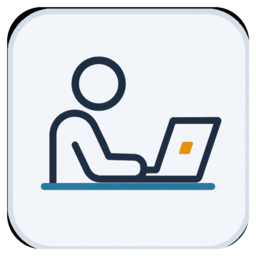 Your Workspace

Paste, read, and run Claude's response in the next cell.


In [ ]:
# YOUR WORKSPACE — Claude Coding Task 2


### 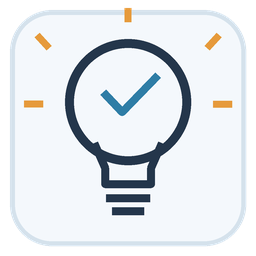 Reference Solution for Task 2


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

model_frame = ad_train.copy()
if "DateTime" in model_frame.columns:
    parsed_time = pd.to_datetime(model_frame["DateTime"], errors="coerce")
    model_frame["hour"] = parsed_time.dt.hour
    model_frame["day_of_week"] = parsed_time.dt.dayofweek

y_all = pd.to_numeric(model_frame["is_click"], errors="coerce")
valid_label = y_all.isin([0, 1])
model_frame = model_frame.loc[valid_label].copy()
y_all = y_all.loc[valid_label].astype(int)

excluded = ["session_id", "user_id", "campaign_id", "webpage_id",
            "user_group_id", "DateTime", "is_click"]
X_all = model_frame.drop(columns=[c for c in excluded if c in model_frame.columns])

preferred_categorical = ["product", "gender", "product_category_1", "product_category_2"]
categorical_features = [c for c in preferred_categorical if c in X_all.columns]
numeric_features = [c for c in X_all.columns if c not in categorical_features]
for c in categorical_features:
    X_all[c] = X_all[c].astype("object").where(X_all[c].notna(), np.nan)
for c in numeric_features:
    X_all[c] = pd.to_numeric(X_all[c], errors="coerce")

if len(X_all) > 12000:
    X_all, _, y_all, _ = train_test_split(
        X_all, y_all, train_size=12000, random_state=1099, stratify=y_all
    )

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.20, random_state=1099, stratify=y_all
)

numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])
categorical_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])
svm_preprocessor = ColumnTransformer([
    ("numeric", numeric_pipe, numeric_features),
    ("categorical", categorical_pipe, categorical_features),
])

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)
print("Training shape:", X_train.shape, "Test shape:", X_test.shape)
display(y_train.value_counts(normalize=True).sort_index().to_frame("train_proportion"))
display(y_test.value_counts(normalize=True).sort_index().to_frame("test_proportion"))


### 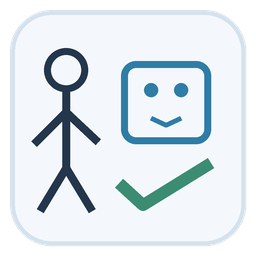 Human Check

> **Domain expertise required:** The questions below are examples, not a complete checklist. Add a check based on the real application; if you lack that expertise, involve someone who has it.

- **Your own domain question:** What could be wrong here that a generic AI system or checklist would be unlikely to notice?


- Which variables were excluded as identifiers?
- Which time features were derived?
- Are numeric and categorical transformations different?
- Was the sample stratified?
- Was the final split stratified?
- Was scaling placed inside the pipeline?
- Can the transformed feature space be much larger than the original column count?

# Part 3: Fit a Linear Support-Vector Classifier

A support-vector classifier depends primarily on observations on or inside the margin. Those observations are the **support vectors**.

The tuning parameter `C` controls the penalty for violations. In scikit-learn's parameterization, a larger `C` penalizes violations more strongly and usually permits a narrower, more flexible fit. A smaller `C` allows more violations and stronger regularization.

Because clicks may be rare, `class_weight="balanced"` is used as an explicit modeling choice.


## 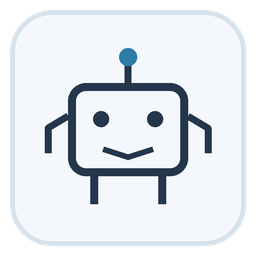 Claude Coding Task 3: Fit the Linear SVM

```text
Using the locked split and svm_preprocessor:

1. create a Pipeline with svm_preprocessor and SVC;
2. use kernel="linear", C=1.0, class_weight="balanced", and
   random_state=1099;
3. do not set probability=True;
4. fit only on X_train and y_train;
5. calculate test classes and decision-function scores;
6. print the number of support vectors for each class;
7. name the pipeline linear_svm;
8. do not tune on the test set.

Return only the Python code.
```

### 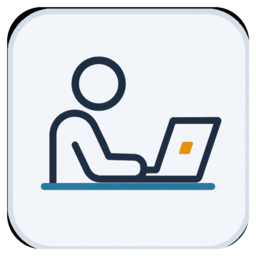 Your Workspace

Paste, read, and run Claude's response in the next cell.


In [ ]:
# YOUR WORKSPACE — Claude Coding Task 3


### 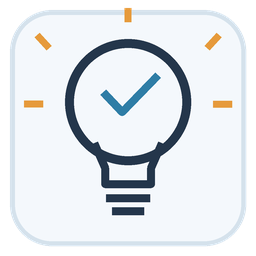 Reference Solution for Task 3


In [ ]:
from sklearn.svm import SVC

linear_svm = Pipeline([
    ("preprocess", svm_preprocessor),
    ("svm", SVC(
        kernel="linear", C=1.0, class_weight="balanced", random_state=1099
    )),
])
linear_svm.fit(X_train, y_train)
linear_pred = linear_svm.predict(X_test)
linear_score = linear_svm.decision_function(X_test)
print("Support vectors by class:", linear_svm.named_steps["svm"].n_support_)
print("Total support vectors:", int(linear_svm.named_steps["svm"].n_support_.sum()))


# Part 4: Evaluate the Boundary, Not Just Accuracy

The decision-function score measures signed distance-like confidence relative to the fitted boundary. It is not a calibrated click probability.

For an imbalanced outcome, compare:

- accuracy;
- balanced accuracy;
- precision for clicks;
- recall for clicks;
- ROC AUC using decision scores;
- the confusion matrix.


## 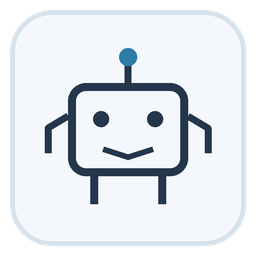 Claude Coding Task 4: Evaluate the Linear Model

```text
Using y_test, linear_pred, and linear_score:

1. calculate accuracy, balanced accuracy, precision, recall, specificity,
   F1, and ROC AUC;
2. display a labeled confusion matrix;
3. plot an ROC curve using linear_score, not predicted classes;
4. print the majority-class baseline accuracy;
5. explicitly label decision scores as scores rather than probabilities;
6. name the metric table linear_metrics.

Return only the Python code.
```

### 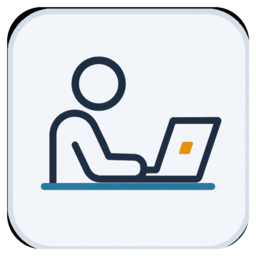 Your Workspace

Paste, read, and run Claude's response in the next cell.


In [ ]:
# YOUR WORKSPACE — Claude Coding Task 4


### 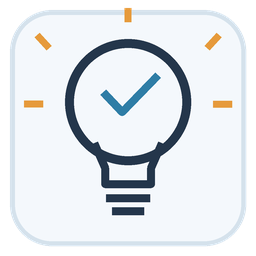 Reference Solution for Task 4


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix
)

tn, fp, fn, tp = confusion_matrix(y_test, linear_pred, labels=[0,1]).ravel()
specificity = tn / (tn + fp) if (tn + fp) else 0.0
linear_metrics = pd.Series({
    "Accuracy": accuracy_score(y_test, linear_pred),
    "Balanced accuracy": balanced_accuracy_score(y_test, linear_pred),
    "Precision (click)": precision_score(y_test, linear_pred, zero_division=0),
    "Recall (click)": recall_score(y_test, linear_pred, zero_division=0),
    "Specificity": specificity,
    "F1 (click)": f1_score(y_test, linear_pred, zero_division=0),
    "ROC AUC": roc_auc_score(y_test, linear_score),
})
display(linear_metrics.to_frame("value").style.format("{:.3f}"))
majority_accuracy = y_test.value_counts(normalize=True).max()
print("Majority-class baseline accuracy:", round(majority_accuracy, 3))

ConfusionMatrixDisplay.from_predictions(
    y_test, linear_pred, display_labels=["No click", "Click"], values_format="d"
)
plt.title("Linear SVM Confusion Matrix")
plt.show()

fpr, tpr, _ = roc_curve(y_test, linear_score)
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"Linear SVM AUC = {linear_metrics['ROC AUC']:.3f}")
plt.plot([0,1],[0,1],"--",label="No-skill reference")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve From Decision Scores"); plt.legend(); plt.show()


### 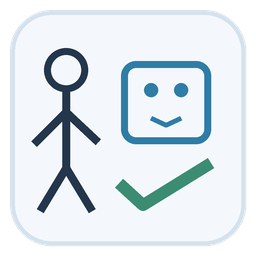 Human Check

> **Domain expertise required:** The questions below are examples, not a complete checklist. Add a check based on the real application; if you lack that expertise, involve someone who has it.

- **Your own domain question:** What could be wrong here that a generic AI system or checklist would be unlikely to notice?


1. How close is model accuracy to the majority baseline?
2. What fraction of actual clicks was recovered?
3. What fraction of predicted clicks was correct?
4. Why can class weighting reduce accuracy while improving click recall?
5. Why was `linear_score` used for ROC AUC?
6. Why must it not be described as a probability?
7. Does a large support-vector count suggest the classes are cleanly separated?

# Part 5: Kernel Method and Representation

A linear boundary may fail when the classes require a curved separation in the original representation.

ISLP first motivates enlarging the feature space with nonlinear functions. A kernel performs the needed similarity calculations without explicitly constructing every coordinate in that enlarged space.

A kernel is a similarity function:

$$K(x_i,x_j).$$

The radial-basis-function kernel is:

$$
K(x_i,x_j)=\exp\left(-\gamma\sum_{k=1}^{p}(x_{ik}-x_{jk})^2\right).
$$

Nearby represented observations have larger similarity. Larger `gamma` makes influence more local and the boundary more flexible. This is why scaling and representation remain central even when the feature map is implicit.


## 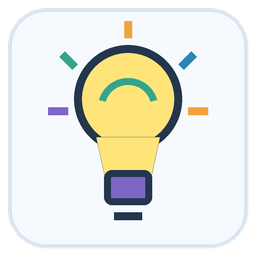 Theory: A Kernel Computes Similarity in a Larger Space

A nonlinear kernel lets the SVM act as though it created additional features without explicitly storing every new coordinate. The RBF kernel assigns greater similarity to nearby represented observations. It can form curved boundaries, but that flexibility still operates on the human-designed preprocessing.

### Deeper explanation

A valid kernel corresponds to an inner product $K(x,z)=\langle\phi(x),\phi(z)\rangle$ in some feature space. Training depends on pairwise kernel values, so $\phi$ need not be written explicitly. The RBF kernel creates flexible local boundaries, but high flexibility can memorize isolated cases. Kernel choice is a representation decision, not a guarantee of nonlinear truth.


## 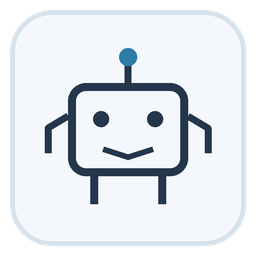 Claude Coding Task 5: Compare Linear and RBF Kernels

```text
Using the same split and svm_preprocessor:

1. create an SVC pipeline with kernel="rbf", C=1.0, gamma="scale",
   class_weight="balanced", and random_state=1099;
2. fit only on X_train and y_train;
3. calculate test predictions and decision scores;
4. create one comparison table for the linear and RBF models with accuracy,
   balanced accuracy, click precision, click recall, F1, ROC AUC, and total
   support-vector count;
5. do not call either kernel best from one split alone;
6. name the fitted model rbf_svm.

Return only the Python code.
```

### 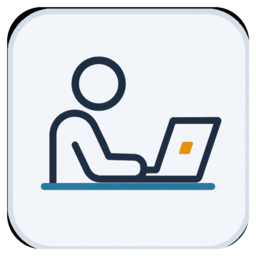 Your Workspace

Paste, read, and run Claude's response in the next cell.


In [ ]:
# YOUR WORKSPACE — Claude Coding Task 5


### 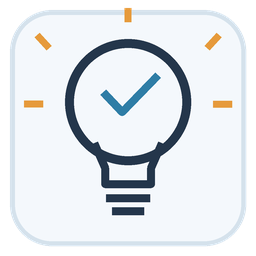 Reference Solution for Task 5


In [ ]:
rbf_svm = Pipeline([
    ("preprocess", svm_preprocessor),
    ("svm", SVC(
        kernel="rbf", C=1.0, gamma="scale",
        class_weight="balanced", random_state=1099
    )),
])
rbf_svm.fit(X_train, y_train)
rbf_pred = rbf_svm.predict(X_test)
rbf_score = rbf_svm.decision_function(X_test)

def svm_row(name, model, pred, score):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "BalancedAccuracy": balanced_accuracy_score(y_test, pred),
        "PrecisionClick": precision_score(y_test, pred, zero_division=0),
        "RecallClick": recall_score(y_test, pred, zero_division=0),
        "F1Click": f1_score(y_test, pred, zero_division=0),
        "ROCAUC": roc_auc_score(y_test, score),
        "SupportVectors": int(model.named_steps["svm"].n_support_.sum()),
    }

svm_comparison = pd.DataFrame([
    svm_row("Linear kernel", linear_svm, linear_pred, linear_score),
    svm_row("RBF kernel", rbf_svm, rbf_pred, rbf_score),
])
display(svm_comparison.style.format({
    "Accuracy":"{:.3f}", "BalancedAccuracy":"{:.3f}",
    "PrecisionClick":"{:.3f}", "RecallClick":"{:.3f}",
    "F1Click":"{:.3f}", "ROCAUC":"{:.3f}",
}))


## 🟢 🔎 Pólya Step 4 — Look Back

**Backbone checkpoint.** Do not stop at “it ran.” Ask whether the result answers the original problem, what evidence supports it, what failed, and what should change. Domain expertise matters here because a generic checklist cannot know every real-world failure mode.

**In this tutorial:** Inspect boundary errors, tuning sensitivity, group performance, and interpretation limits.

### 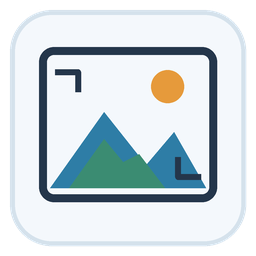 Look Back

1. Which kernel recovers more actual clicks?
2. Which produces fewer false click predictions?
3. Does the nonlinear kernel materially improve balanced accuracy or ROC AUC?
4. What representation choices occurred before the kernel calculation?
5. Why is the RBF feature space called implicit?
6. What happens to locality as `gamma` increases?
7. Why would tuning `C` and `gamma` on the test set be invalid?
8. What information is lost when identifiers are excluded, and what leakage risk is reduced?


# AI for Social Good: A Decision Boundary Can Shape Opportunity

The earlier course examined digital platforms as social and economic systems, not just prediction problems. An ad-click classifier is a useful example because a decision boundary can determine who sees products, jobs, housing, financial offers, political messages, or other opportunities.

A high-performing SVM can still create problems when:

- demographic variables or proxies determine exposure;
- optimizing click-through rewards attention rather than user benefit;
- historical behavior is amplified into future opportunity;
- a minority class is hidden by strong overall accuracy;
- users cannot see why an item was shown or withheld;
- the platform’s objective differs from the welfare of the people using it.

Kernel methods make the boundary more flexible, but also make it harder to explain which combinations of features drove a result. That increases the importance of subgroup evaluation, documentation, and human review.

> **Social-good principle:** A representation encodes a theory of which differences matter; a decision boundary turns that theory into differential treatment.


# Tutorial 9 Conclusion

You used Claude to inspect the original ad-click files, build a mixed-data representation, fit a linear support-vector classifier, evaluate the minority click class, and compare a linear boundary with an RBF kernel.

The central lesson is that kernels can create flexible boundaries through similarity in an implicit feature space, but every kernel still operates on the representation the human designed.


# 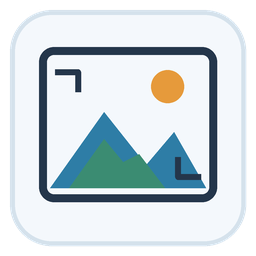 Final Reflection

1. What is a separating hyperplane?
2. What is the margin?
3. Which observations become support vectors?
4. What does `C` control?
5. Why was scaling necessary?
6. What did one-hot encoding change about the feature space?
7. How does an RBF kernel measure similarity?
8. What does `gamma` control?
9. Why is a decision score not a probability?
10. What did Claude make easier?
11. Which representation choices remained human responsibilities?


# 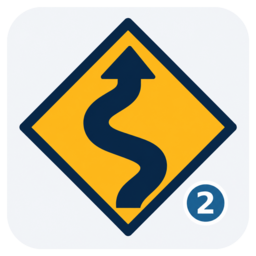 Level 2 — Optional Deep Dive

> **Challenge ahead:** Complete Level 1 first; this optional route adds a harder application of the same reading.

# Part 6: Tune `C` and `gamma` Inside the Training Data

Flexible kernels create a bias-variance tradeoff.

- Very small `C` can underfit by allowing many violations.
- Very large `C` can chase training observations.
- Small `gamma` produces broad influence and a smoother boundary.
- Large `gamma` produces local influence and a more irregular boundary.

These parameters must be selected with cross-validation inside the training data.


## 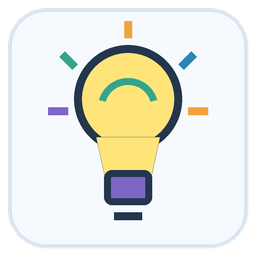 Theory: `C` and `gamma` Control Different Kinds of Flexibility

`C` controls the penalty for margin violations. `gamma` controls how local each observation’s influence is in the RBF kernel. Their effects interact, so both are compared with cross-validation inside the training data rather than selected from the final test result.

### Deeper explanation

$C$ controls the penalty for margin violations; $\gamma$ controls the radius of influence in an RBF kernel. Large values of both can create a highly local boundary with low training error and high variance. Small $C$ with small $\gamma$ can underfit. They must be tuned jointly because a change in one can alter the useful range of the other.


## 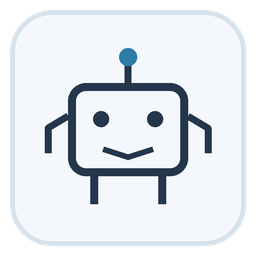 Claude Coding Task 6: Cross-Validate the SVM

```text
Using only X_train and y_train:

1. create a pipeline with svm_preprocessor and SVC using
   class_weight="balanced" and random_state=1099;
2. use StratifiedKFold with 4 splits, shuffle=True, random_state=1099;
3. compare kernel="linear" with C in [0.1, 1, 10];
4. compare kernel="rbf" with C in [0.1, 1, 10] and gamma in
   ["scale", 0.01, 0.1];
5. use a list of parameter grids so gamma is not applied to the linear model;
6. score with balanced_accuracy and refit the best model;
7. print best parameters and CV score;
8. evaluate the untouched test set once;
9. name the search svm_search and the selected pipeline tuned_svm.

Return only the Python code.
```

### 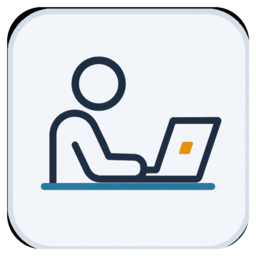 Your Workspace

Paste, read, and run Claude's response in the next cell.


In [ ]:
# YOUR WORKSPACE — Claude Coding Task 6


### 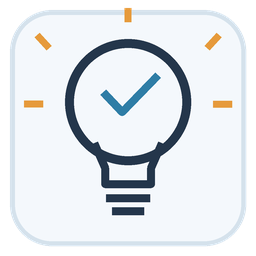 Reference Solution for Task 6


In [ ]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

svm_tuning_pipeline = Pipeline([
    ("preprocess", svm_preprocessor),
    ("svm", SVC(class_weight="balanced", random_state=1099)),
])
svm_parameter_grids = [
    {"svm__kernel": ["linear"], "svm__C": [0.1, 1, 10]},
    {"svm__kernel": ["rbf"], "svm__C": [0.1, 1, 10],
     "svm__gamma": ["scale", 0.01, 0.1]},
]
svm_cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=1099)
svm_search = GridSearchCV(
    svm_tuning_pipeline, svm_parameter_grids,
    scoring="balanced_accuracy", cv=svm_cv, n_jobs=-1, refit=True
)
svm_search.fit(X_train, y_train)
tuned_svm = svm_search.best_estimator_
tuned_pred = tuned_svm.predict(X_test)
tuned_score = tuned_svm.decision_function(X_test)
print("Best parameters:", svm_search.best_params_)
print("Best CV balanced accuracy:", round(svm_search.best_score_, 3))
display(pd.Series({
    "Test balanced accuracy": balanced_accuracy_score(y_test, tuned_pred),
    "Test click recall": recall_score(y_test, tuned_pred, zero_division=0),
    "Test ROC AUC": roc_auc_score(y_test, tuned_score),
}).to_frame("value").style.format("{:.3f}"))


# Part 7: Descriptive Error Audit by Gender

The supplied `gender` field can be used for a descriptive audit if it is present in `X_test`. This does not establish discrimination or causation. It asks whether observed error rates differ across the available groups.


## 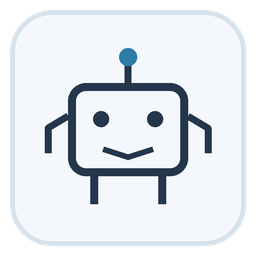 Claude Coding Task 7: Compare Group Error Rates

```text
Using tuned_pred and the original gender values in X_test:

1. verify that gender is present;
2. create a row-level audit table with actual, predicted, correct, false
   positive, and false negative indicators;
3. group by gender and report count, click prevalence, accuracy, click recall,
   false-positive rate, and false-negative rate;
4. suppress a rate when its denominator is zero;
5. do not claim that gender caused any difference;
6. print a warning for groups with fewer than 30 observations.

Return only the Python code.
```

### 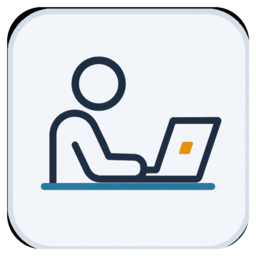 Your Workspace

Paste, read, and run Claude's response in the next cell.


In [ ]:
# YOUR WORKSPACE — Claude Coding Task 7


### 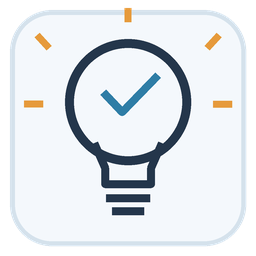 Reference Solution for Task 7


In [ ]:
assert "gender" in X_test.columns, "The supplied representation does not include gender."
audit = pd.DataFrame({
    "gender": X_test["gender"].astype("string"),
    "actual": y_test.astype(int),
    "predicted": tuned_pred,
}, index=X_test.index)

def group_rates(group):
    actual=group["actual"].to_numpy(); pred=group["predicted"].to_numpy()
    tn, fp, fn, tp = confusion_matrix(actual, pred, labels=[0,1]).ravel()
    return pd.Series({
        "n": len(group),
        "click_prevalence": actual.mean(),
        "accuracy": (actual==pred).mean(),
        "click_recall": tp/(tp+fn) if (tp+fn) else np.nan,
        "false_positive_rate": fp/(fp+tn) if (fp+tn) else np.nan,
        "false_negative_rate": fn/(fn+tp) if (fn+tp) else np.nan,
    })

gender_audit = audit.groupby("gender", dropna=False).apply(group_rates, include_groups=False)
display(gender_audit.style.format({c:"{:.3f}" for c in gender_audit.columns if c!="n"}))
small_groups = gender_audit.index[gender_audit["n"] < 30].tolist()
if small_groups:
    print("Warning: groups with fewer than 30 test observations:", small_groups)


# 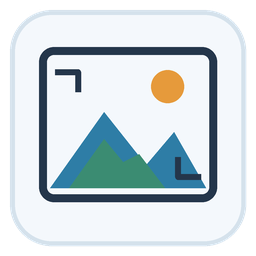 Level 2 Look Back

1. Which tuning parameter changed the selected boundary most?
2. Did cross-validation prefer a linear or nonlinear kernel?
3. Were subgroup rates stable enough to interpret?
4. Could other represented variables act as gender proxies?
5. What data would be needed to determine whether the model changes opportunity or only predicts clicks?


# Sources and Course Resources

- James, Gareth, Daniela Witten, Trevor Hastie, Robert Tibshirani, and Jonathan Taylor. _An Introduction to Statistical Learning with Applications in Python_, Chapter 9.
- Original dataset: [Click-Through Rate Prediction via Kaggle](https://www.kaggle.com/datasets/arashnic/ctr-in-advertisement).
- Kearns, Michael, and Aaron Roth. _The Ethical Algorithm_. Oxford University Press, 2019. **Background social-good reference; not assigned.**
- Original tutorial context: digital advertising, ad auctions, and the gig economy.
